In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install ultralytics --quiet
import ultralytics
ultralytics.checks()

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 6960.3/8062.4 GB disk)


## Loading the data

In [3]:
import os
from pathlib import Path

DATASET_ROOT = Path('/kaggle/input/datasets/pkdarabi/cardetection/car')


class_ids = set()
label_dir = DATASET_ROOT / 'train' / 'labels'

for lf in label_dir.glob('*.txt'):
    with open(lf) as f:
        for line in f:
            line = line.strip()
            if line:
                cls = int(line.split()[0])
                class_ids.add(cls)

num_classes = max(class_ids) + 1
print(f'Unique class IDs found: {sorted(class_ids)}')
print(f'Number of classes (nc): {num_classes}')

# Count images
for split in ['train', 'valid', 'test']:
    n = len(list((DATASET_ROOT / split / 'images').glob('*')))
    print(f'{split}: {n} images')

Unique class IDs found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Number of classes (nc): 15
train: 3530 images
valid: 801 images
test: 638 images


## Let's leave class names with numbers for now. We can change it later.

In [4]:
CLASS_NAMES = [f'class_{i}' for i in range(num_classes)] 

print('Class names:', CLASS_NAMES)

Class names: ['class_0', 'class_1', 'class_2', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7', 'class_8', 'class_9', 'class_10', 'class_11', 'class_12', 'class_13', 'class_14']


In [5]:
import yaml

data_config = {
    'path': str(DATASET_ROOT),
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc': num_classes,
    'names': CLASS_NAMES
}

yaml_path = '/kaggle/working/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print('data.yaml saved:')
print(open(yaml_path).read())

data.yaml saved:
names:
- class_0
- class_1
- class_2
- class_3
- class_4
- class_5
- class_6
- class_7
- class_8
- class_9
- class_10
- class_11
- class_12
- class_13
- class_14
nc: 15
path: /kaggle/input/datasets/pkdarabi/cardetection/car
test: test/images
train: train/images
val: valid/images



## Training process:
### Losses (lower = better, should decrease over epochs)
### * Box loss - how accurately the model predicts the bounding box position and size
### * Class loss - how accurately the model identifies which class the object belongs to
### * DFL loss (Distribution Focal Loss) - fine-grained box edge localization; helps the model be more precise about where exactly the box boundary is

### Metrics (higher = better)

### * mAP50 - mean Average Precision at IoU threshold 0.50; a detection counts as correct if the predicted box overlaps the ground truth by ≥50%—the main metric to watch.
### * mAP50-95 - same but averaged across IoU thresholds from 0.50 to 0.95 in steps of 0.05; stricter, better reflects real-world quality

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')  # downloads pretrained weights automatically

results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,          # early stopping: stop if no improvement for 10 epochs
    device=0,             # GPU
    project='/kaggle/working/runs',
    name='road_signs_v1',
    exist_ok=True,
    cache=True,           # cache images in RAM for faster training
    plots=True            
)

In [7]:
best_model = YOLO('/kaggle/working/runs/road_signs_v1/weights/best.pt')

metrics = best_model.val(data=yaml_path)
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,131,389 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 19.9±14.9 MB/s, size: 13.3 KB)
val: Scanning /kaggle/input/datasets/pkdarabi/cardetection/car/valid/labels... 801 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 801/801 768.9it/s 1.0s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/pkdarabi/cardetection/car/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 4.7it/s 10.8s0.2s
                   all        801        944       0.96      0.948      0.971      0.837
               class_0         87        122      0.895      0.844       0.89      0.534
               class_1         74        108      0.871      0.787      0.838      0.523
               class_3         52         52      0.941          1      

## Great results! mAP50:     0.9714 and mAP50-95:  0.8366

### Renaming our class names from numbers to real road signs' names


In [14]:
best_model = YOLO('/kaggle/working/runs/road_signs_v1/weights/best.pt')

# Rename classes
CLASS_NAMES = [
    'Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100',
    'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30',
    'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70',
    'Speed Limit 80', 'Speed Limit 90', 'Stop'
]
best_model.model.names = {i: name for i, name in enumerate(CLASS_NAMES)}

In [16]:
print(best_model.names)

{0: 'Green Light', 1: 'Red Light', 2: 'Speed Limit 10', 3: 'Speed Limit 100', 4: 'Speed Limit 110', 5: 'Speed Limit 120', 6: 'Speed Limit 20', 7: 'Speed Limit 30', 8: 'Speed Limit 40', 9: 'Speed Limit 50', 10: 'Speed Limit 60', 11: 'Speed Limit 70', 12: 'Speed Limit 80', 13: 'Speed Limit 90', 14: 'Stop'}


## Let's see some examples


image 1/4 /kaggle/input/datasets/pkdarabi/cardetection/car/test/images/000664_jpg.rf.882fdd90b90c7f1af1fc37a7467443cf.jpg: 640x640 1 Speed Limit 50, 1 Speed Limit 80, 16.1ms
image 2/4 /kaggle/input/datasets/pkdarabi/cardetection/car/test/images/000822_jpg.rf.63b8e6ec737487b4e7e9e2ed48754226.jpg: 640x640 1 Speed Limit 90, 16.2ms
image 3/4 /kaggle/input/datasets/pkdarabi/cardetection/car/test/images/001051_jpg.rf.bb8152d7d7c35ed73bfc9239185f9087.jpg: 640x640 2 Speed Limit 100s, 1 Speed Limit 80, 16.1ms
image 4/4 /kaggle/input/datasets/pkdarabi/cardetection/car/test/images/00014_00023_00018_png.rf.7f4df748842e9a2b90d343c5612ff812.jpg: 640x640 1 Stop, 16.1ms
Speed: 2.1ms preprocess, 16.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/predict_test_named-5


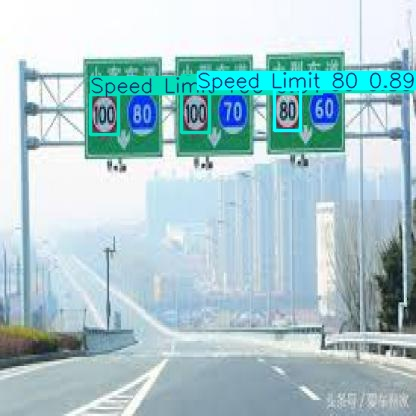

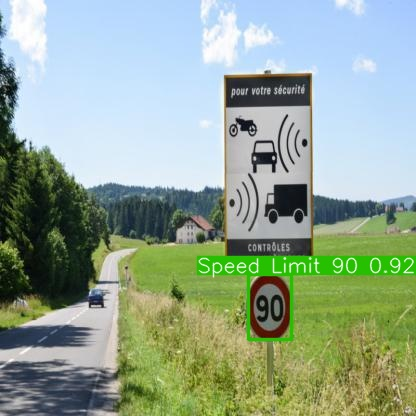

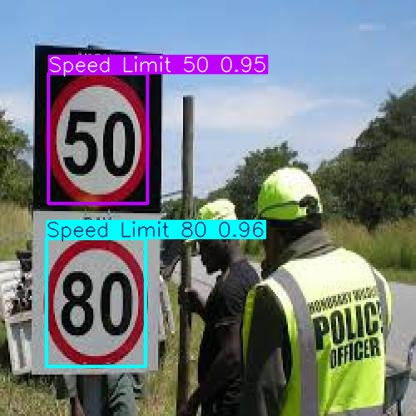

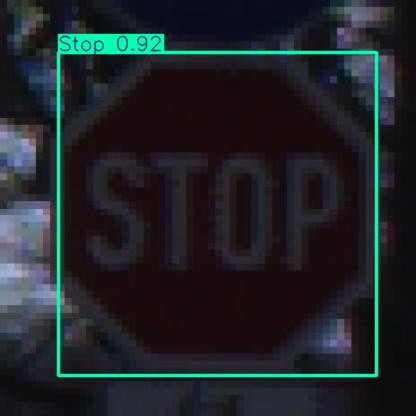

In [21]:
import glob
from IPython.display import Image, display

best_model.predictor = None  

results = best_model.predict(test_images, conf=0.25, save=True,
                              project='/kaggle/working/runs',
                              name='predict_test_named')

pred_imgs = glob.glob('/kaggle/working/runs/predict_test_named/*.jpg') + \
            glob.glob('/kaggle/working/runs/predict_test_named/*.png')
for img in pred_imgs[:4]:
    display(Image(img))

## YOLO's metrics during the training

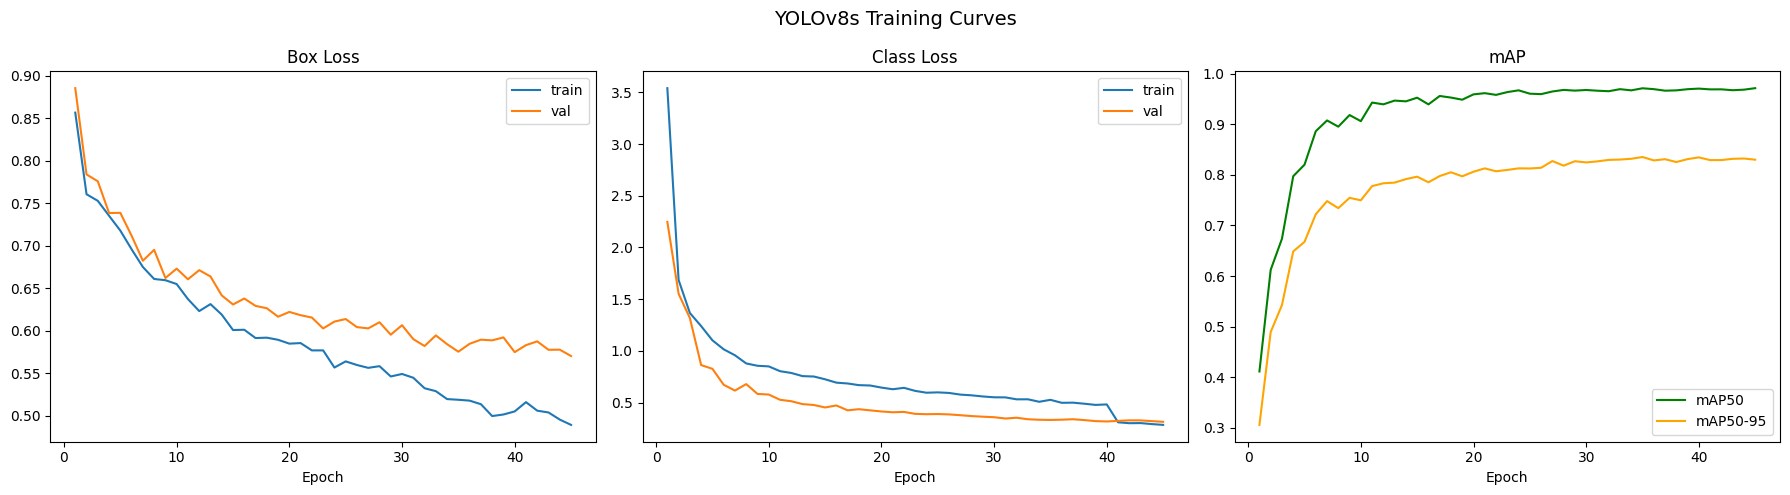

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = '/kaggle/working/runs/road_signs_v1/results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()  # remove accidental whitespace

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('YOLOv8s Training Curves', fontsize=14)

# Box loss
axes[0].plot(df['epoch'], df['train/box_loss'], label='train')
axes[0].plot(df['epoch'], df['val/box_loss'],   label='val')
axes[0].set_title('Box Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Class loss
axes[1].plot(df['epoch'], df['train/cls_loss'], label='train')
axes[1].plot(df['epoch'], df['val/cls_loss'],   label='val')
axes[1].set_title('Class Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# mAP50
axes[2].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='green')
axes[2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='orange')
axes[2].set_title('mAP')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

## Let's check our model on a video

In [ ]:
video_path = '/kaggle/input/datasets/pkdarabi/cardetection/video.mp4'

best_model.predictor = None  # reset predictor

results = best_model.predict(
    source=video_path,
    conf=0.25,
    save=True,
    project='/kaggle/working/runs',
    name='video_output'
)
print("Video saved")